<h1>📊 Análise de Vendas e Impacto de Descontos</h1>

<h2>1. Contexto de negócio</h2>
<p style="font-size:17px;">Em mercados competitivos, descontos são frequentemente utilizados como mecanismo para estimular vendas, aumentar participação de mercado e acelerar o giro comercial.</p>
<p style="font-size:17px;">Entretanto, existe uma questão estratégica relevante:</p>
<p style="font-size:17px;"><b>até que ponto conceder descontos contribui para o crescimento do negócio sem comprometer sua rentabilidade?</b></p>
<p style="font-size:17px;">Este projeto investiga essa relação a partir de uma base transacional de vendas, buscando entender como diferentes níveis de desconto impactam faturamento, lucro, margem e ticket médio.</p>

<h2>2. Objetivo da análise</h2>

<p style="font-size:17px;">O objetivo central deste estudo é avaliar se a política comercial de descontos está efetivamente gerando valor econômico para a operação.</p>

<p style="font-size:17px;">Mais especificamente, a análise busca responder:</p>
<ul style="font-size:17px;">
    <li>Os descontos aumentam resultado financeiro ou apenas reduzem receita?</li>
    <li>Existe um limite a partir do qual o desconto passa a destruir margem?</li>
    <li>Quais regiões e categorias são mais sensíveis à política de preços?</li>
    <li>O comportamento se mantém consistente ao longo do tempo?</li>
</ul>

<h2>3. Fonte dos dados</h2>

<p style="font-size:17px;">A base utilizada neste estudo é o conjunto sales dataset, disponibilizado por VINOTH KANNA na plataforma Kaggle.</p>

<p style="font-size:17px;">Características da base:</p>
<ul style="font-size:17px;">
    <li>1.000 registros de vendas</li>
    <li>Período entre janeiro de 2023 e janeiro de 2024</li>
    <li>Comparação entre cenários com e sem desconto;</li>
    <li>Variáveis de preço, custo, desconto, categoria, região, canal e cliente</li>
    <li>Endereço: https://www.kaggle.com/datasets/vinothkannaece/sales-dataset</li>
</ul>

---

<h2>4. Bibliotecas utilizadas</h2>

In [1]:
# Biblioteca para análise de dados, cálculos matemáticos e geração de gráficos em Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---

<h2>5. Leitura dos dados</h2>
<p style="font-size:17px;">Nesta etapa, carregamos os conjuntos de dados.</p>

In [2]:
arquivo_vendas = "/kaggle/input/datasets/vinothkannaece/sales-dataset/sales_data.csv"
df = pd.read_csv(arquivo_vendas)

---

<h2>6. Visualização inicial dos dados</h2>

<p  style="font-size:17px;">Abaixo apresentamos as primeiras linhas do dataset para compreender sua estrutura, colunas disponíveis e possíveis inconsistências iniciais.</p>

In [3]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


<h2>Observações iniciais</h2>

<ul style="font-size:17px;">
    <li>O dataset contém informações sobre vendas</li>
    <li>Há variáveis categóricas(ex: Region), numéricas(ex: Sales_Amount) e do tipo data(ex: Sale_Date)</li>
    <li>Aparentemente sem valores nulos, incorretos, duplicados ou inconsistentes.</li>
</ul>

---

<h2>7. Estrutura dos dados</h2>

<p style="font-size:17px;">Nesta etapa, analisamos os tipos de dados, a quantidade de registros, a quantidade e nomes das colunas e memória utilizada.</p>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


<h2>Principais pontos</h2>

<ul style="font-size:17px;">
    <li>O dataset possui 1000 linhas e 14 colunas</li>
    <li>Variáveis numéricas estão representadas como `int64` e `float64`</li>
    <li>Variáveis categóricas estão como `object` (texto)</li>
    <li>A coluna `Sale_Date` precisará de conversão para `datetime`</li>    
    <li>Sem valores nulos</li>
</ul>

---

<h2>8. Conversão de tipo</h2>

<p style="font-size:17px;">A coluna data de venda (`Sale_Date`) será convertida para o tipo `datatime`</p>

In [5]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], errors="coerce")

---

<h2>9. Teste de qualidade dos dados</h2>

<p style="font-size:17px;">A função implementa uma série de testes para garantir a qualidade dos dados</p>

In [6]:
def checklist_qualidade(df):
    print("🔍 CHECKLIST DE QUALIDADE DE DADOS\n")
    
    # Padronização
    df = df.replace(['', ' ', 'NA', 'N/A', 'null', None, '-'], pd.NA)

    # Informações gerais
    print("📌 Shape:", df.shape)

    # Nulos
    nulos = df.isna().sum().sum()

    if nulos > 0:
        print("⚠️ Valores Nulos:", nulos)
    else:
        print("📌 Valores Nulos:", nulos)

    # Duplicados
    duplicados = df.duplicated().sum()

    if duplicados > 0:
        print("⚠️ Valores Duplicados:", duplicados)
    else:
        print("📌 Valores Duplicados:", duplicados)

    # Negativos
    negativos = (df.select_dtypes(include="number") < 0).sum().sum()

    if negativos > 0:
        print("⚠️ Valores Negativos:", negativos)
    else:
        print("📌 Valores Negativos:", negativos)


    # Datas
    if "Sale_Date" in df.columns:

        # Tipo da data
        if not pd.api.types.is_datetime64_any_dtype(df["Sale_Date"]):
            print("⚠️ Tipagem da data:", df["Sale_Date"].dtype)
        else:
            print("📌 Tipagem da data:", df["Sale_Date"].dtype)

        # Datas nulas
        print("📌 Datas nulas:", df["Sale_Date"].isna().sum())

        # Datas mín e máx
        print("📌 Data mínima:", df["Sale_Date"].min())
        print("📌 Data máxima:", df["Sale_Date"].max())

        # Datas futuras
        futuras = (df["Sale_Date"] > pd.Timestamp.today()).sum()

        if futuras > 0:
            print("⚠️ Datas futuras:", futuras)
        else:
            print("📌 Datas futuras:", futuras)

    # Regras de negócio
    colunas_financeiras = ["Unit_Price", "Unit_Cost", "Discount"]

    if all(col in df.columns for col in colunas_financeiras):

        faturamento_sem_desc = (
            df["Unit_Price"] < df["Unit_Cost"]
        ).sum()

        faturamento_com_desc = (
            (df["Unit_Price"] * (1 - df["Discount"])) < df["Unit_Cost"]
        ).sum()

        total = len(df)

        if faturamento_sem_desc > 0:
            print(
                f"⚠️ Faturamento sem desconto (inconsistências): "
                f"{faturamento_sem_desc} ({faturamento_sem_desc / total:.2%})"
            )
        else:
            print(
                f"📌 Faturamento sem desconto (inconsistências): "
                f"{faturamento_sem_desc} ({faturamento_sem_desc / total:.2%})"
            )

        if faturamento_com_desc > 0:
            print(
                f"⚠️ Faturamento com desconto (inconsistências): "
                f"{faturamento_com_desc} ({faturamento_com_desc / total:.2%})"
            )
        else:
            print(
                f"📌 Faturamento com desconto (inconsistências): "
                f"{faturamento_com_desc} ({faturamento_com_desc / total:.2%})"
            )

checklist_qualidade(df)

🔍 CHECKLIST DE QUALIDADE DE DADOS

📌 Shape: (1000, 14)
📌 Valores Nulos: 0
📌 Valores Duplicados: 0
📌 Valores Negativos: 0
📌 Tipagem da data: datetime64[ns]
📌 Datas nulas: 0
📌 Data mínima: 2023-01-01 00:00:00
📌 Data máxima: 2024-01-01 00:00:00
📌 Datas futuras: 0
📌 Faturamento sem desconto (inconsistências): 0 (0.00%)
⚠️ Faturamento com desconto (inconsistências): 604 (60.40%)


<h2>Resultado da validação</h2>

<p style="font-size:17px;">A base apresentou boa consistência estrutural.</p>
<p style="font-size:17px;">No entanto, surgiu um primeiro sinal relevante:</p>
<p style="font-size:17px;">60,4% das transações com desconto apresentaram preço líquido inferior ao custo unitário.</p>
<p style="font-size:17px;">Esse achado já sugere que a política comercial pode estar comprometendo a rentabilidade operacional.</p>

---

<h2>⚠️ Nota metodológica sobre Faturamento e Sales_Amount</h2>

<p style="font-size:17px;">
De acordo com o dicionário do conjunto de dados, <strong>Sales_Amount</strong> representa o valor total da venda, já considerando eventuais descontos aplicados.
</p>

<p style="font-size:17px;">
Neste projeto, optou-se por não utilizar <strong>Sales_Amount</strong> como base principal das métricas de faturamento, lucro e margem.
Em vez disso, foi adotada uma métrica analítica construída a partir de
<strong>Quantity_Sold</strong>, <strong>Unit_Price</strong>, <strong>Unit_Cost</strong> e <strong>Discount</strong>.
</p>

<p style="font-size:17px;">
Essa escolha metodológica permite analisar de forma mais direta o efeito operacional de preço, volume e desconto sobre a rentabilidade, preservando consistência interna nas métricas utilizadas ao longo da análise.
</p>

---

<h2>10. Criação dos principais KPIs</h2>

In [7]:
# KPIs Financeiros - Métricas base
df["faturamento_sem_desc"] = df["Quantity_Sold"] * df["Unit_Price"]
df["faturamento_com_desc"] = df["Quantity_Sold"] * df["Unit_Price"] * (1 - df["Discount"])
df["custo"] = df["Quantity_Sold"] * df["Unit_Cost"]
df["lucro_sem_desc"] = df["faturamento_sem_desc"] - df["custo"]
df["lucro_com_desc"] = df["faturamento_com_desc"] - df["custo"]
df["margem_com_desc"] = df["lucro_com_desc"] / df["faturamento_com_desc"]
df["margem_sem_desc"] = df["lucro_sem_desc"] / df["faturamento_sem_desc"]

---

<h2>11. Estatística</h2>

In [8]:
df.describe(include="number")

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount,faturamento_sem_desc,faturamento_com_desc,custo,lucro_sem_desc,lucro_com_desc,margem_com_desc,margem_sem_desc
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239,70329.940710,59686.173284,63842.093640,6487.847070,-4155.920356,-0.021608,0.142757
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720,57783.299413,49696.370608,55398.598783,5444.188837,11291.253726,0.211082,0.154231
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000,211.180000,154.161400,60.280000,17.360000,-54935.730000,-0.402296,0.002215
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000,23363.535000,19710.004375,18591.320000,1892.302500,-8178.629325,-0.165445,0.048518
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000,54519.175000,45703.685300,48453.135000,5236.825000,-1210.456500,-0.045353,0.093993
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000,105855.845000,91333.039050,97755.397500,9935.082500,1874.734775,0.063047,0.163021
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000,252147.360000,249625.886400,235808.090000,23441.110000,20832.446400,0.820913,0.841738


<h2>Interpretação</h2>

<p style="font-size:17px;">
    A base analisada contém 1.000 registros de vendas, o que fornece uma amostra consistente para avaliação do desempenho comercial.
</p>

<h3>Visão geral das vendas</h3>
<p style="font-size:17px;">
    O volume médio por transação é de 25,4 unidades (Quantity_Sold), com grande dispersão (std = 14,16), o que indica heterogeneidade         relevante entre pedidos, coexistem vendas pequenas e grandes.
</p>
<p style="font-size:17px;">
    Em média, cada transação apresentou quantidade vendida de 25 unidades, com preço unitário médio de 2.728,44 e custo unitário médio 
    de 2.475,30. O desconto médio aplicado foi de 15,24%, indicando uma política comercial relativamente frequente de concessão 
    de descontos.
</p>
<p style="font-size:17px;">
    Em termos financeiros, o faturamento médio sem desconto foi de 70.329,94, enquanto o faturamento médio com desconto caiu 
    para 59.686,17, evidenciando impacto direto das reduções de preço sobre a receita. O custo médio por operação foi de 63.842,09.
</p>

<h3>Ao comparar os cenários, com e sem descontos, observa-se que:</h3>
<ul style="font-size:17px;">
    <li>Em 50% das vendas, o lucro com desconto ficou abaixo de -1.210,46.</li>
    <li>Já sem desconto, a mediana do lucro foi 5.236,83.</li>
</ul>
<p style="font-size:17px;">
    Isso reforça que o impacto negativo dos descontos não se limita a poucos casos extremos, mas aparece de forma recorrente em boa 
    parte das operações.
</p>
<p style="font-size:17px;">
    Conclusão: de forma geral, os dados indicam que a empresa possui estrutura de preço capaz de gerar lucro sem descontos, porém o 
    nível médio de desconto atualmente praticado compromete a margem operacional, sugerindo a necessidade de revisão da 
    política comercial ou segmentação mais criteriosa dos descontos concedidos.
</p>

---

<h2>12. DashBoard do comportamento comercial</h2>

<p style="font-size:17px;">⚠️ Observação: as métricas utilizadas neste dashboard são todas sem desconto. O motivo desta escolha foi demonstrar o comportamento comercial independente dos descontos.</p>

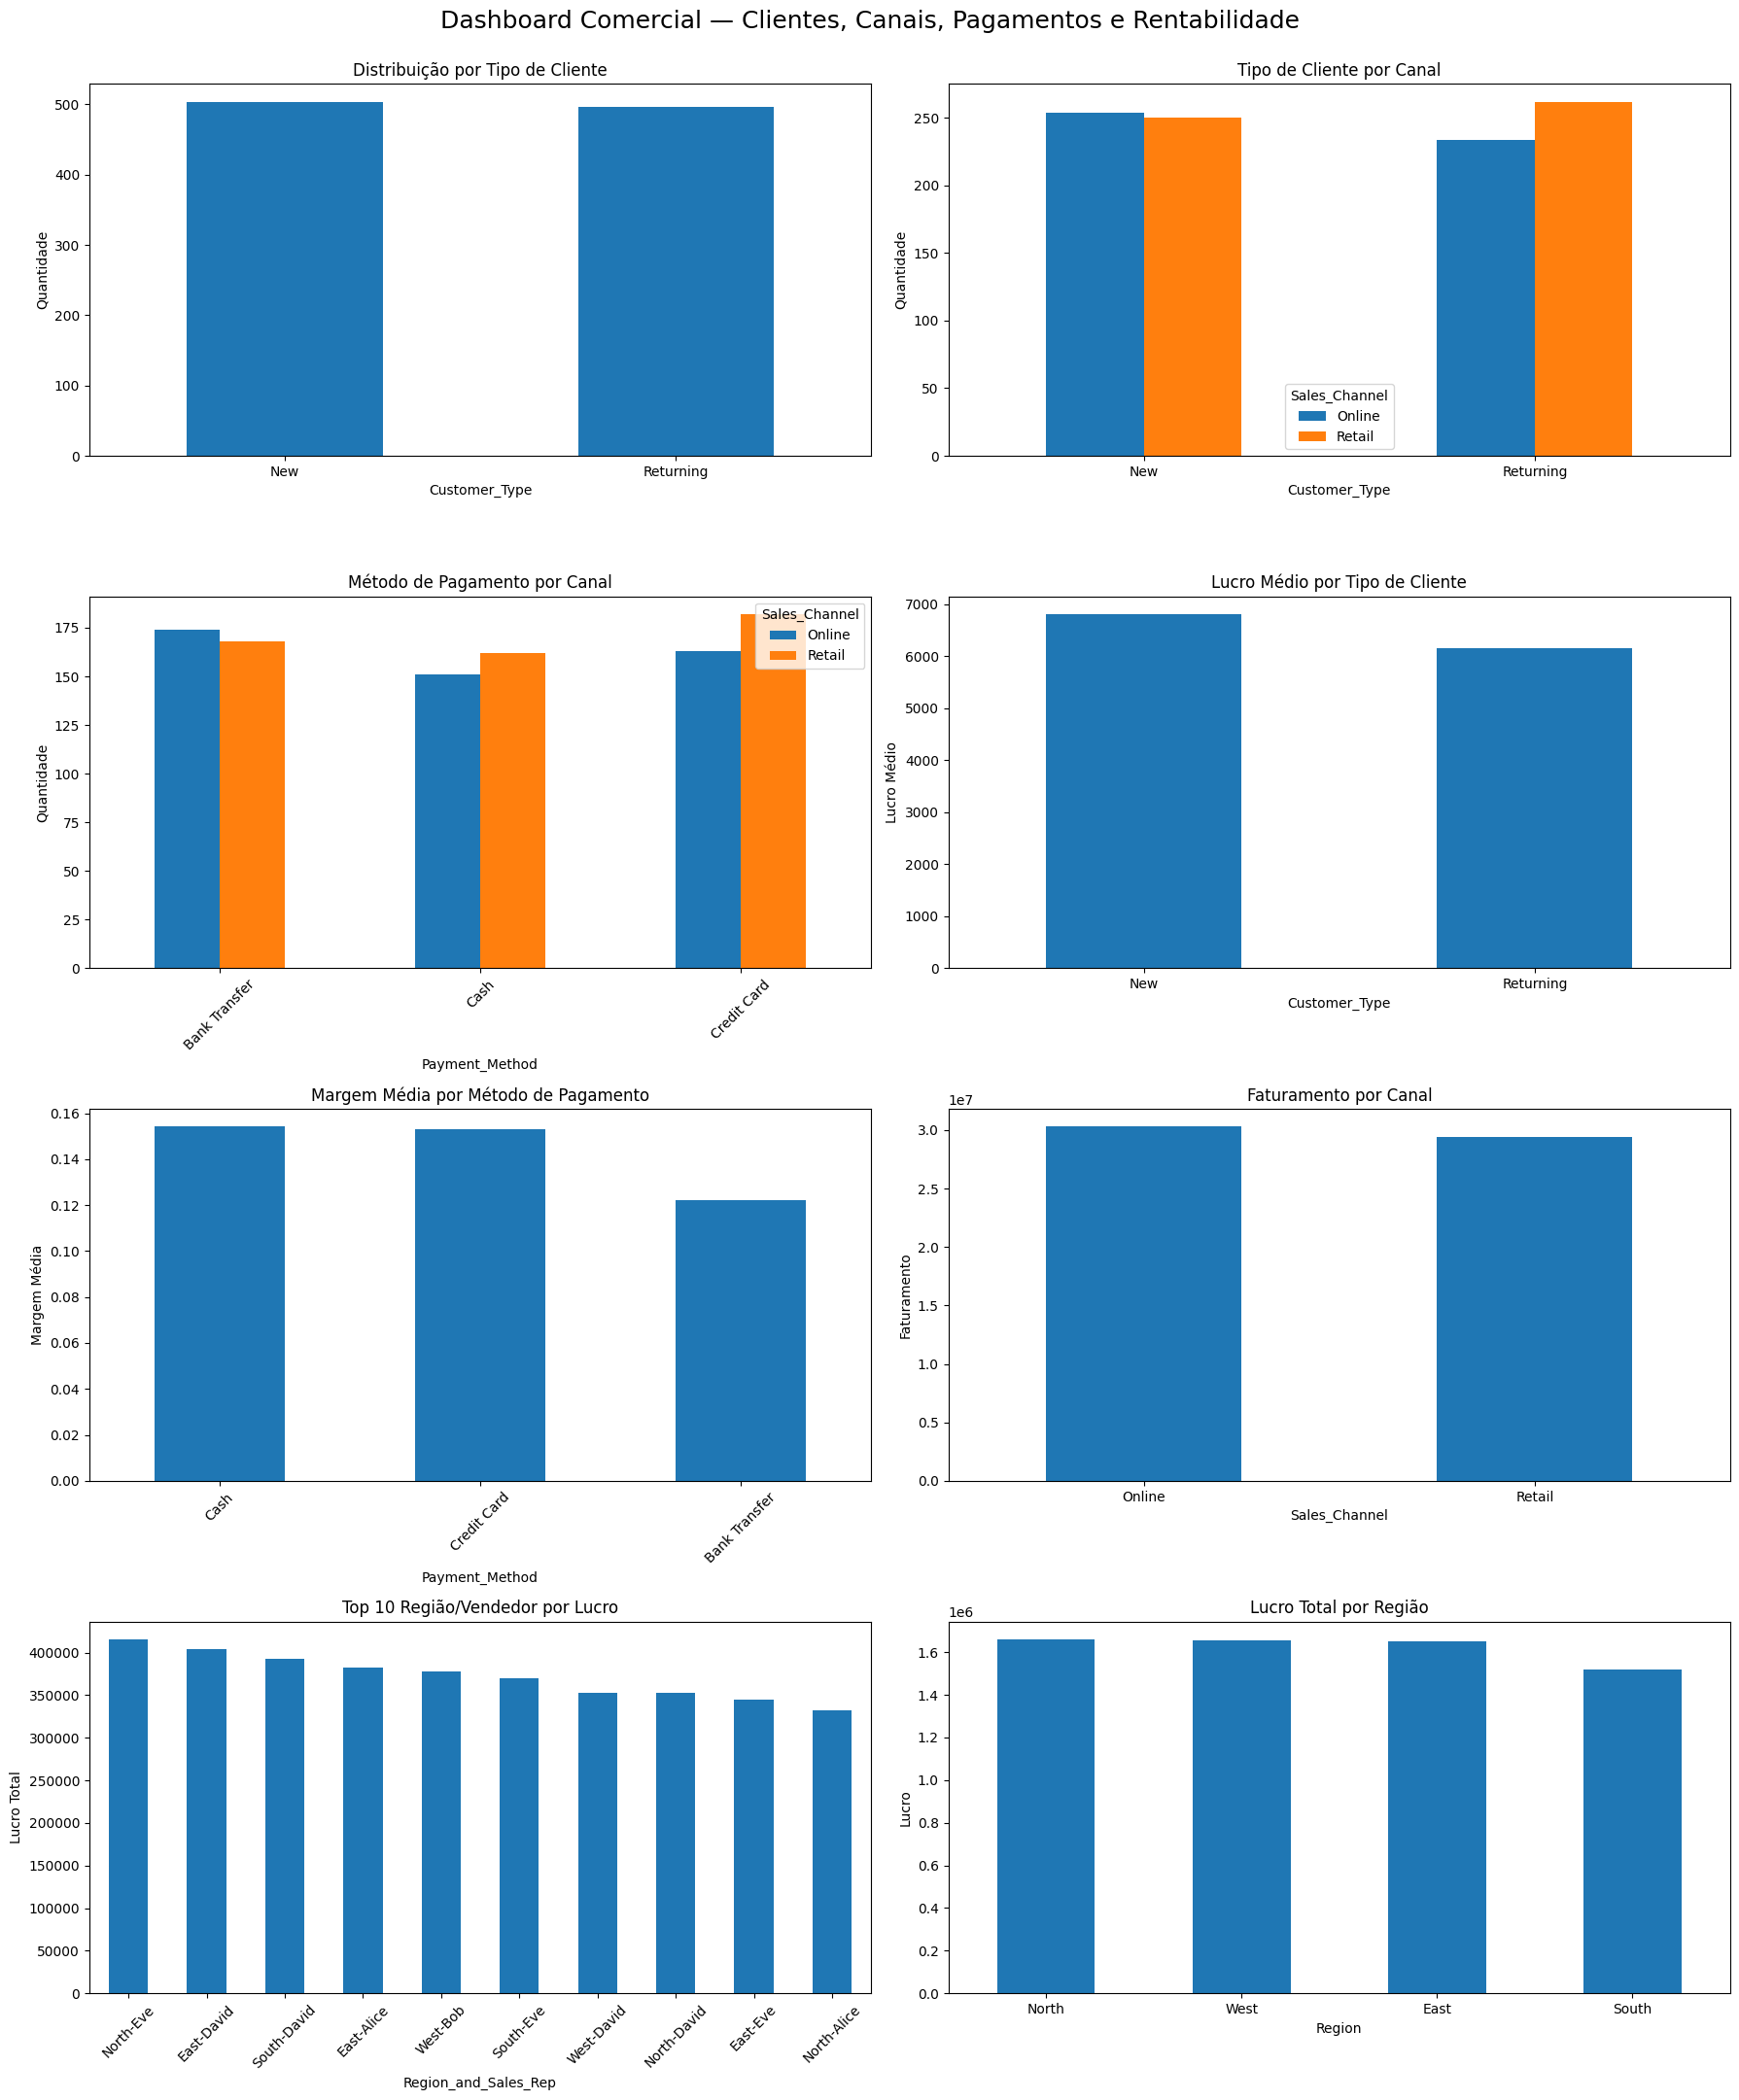

In [9]:
# -----------------------------
# Preparação de agregações
# -----------------------------
customer_counts = df["Customer_Type"].value_counts()

customer_channel = pd.crosstab(
    df["Customer_Type"],
    df["Sales_Channel"]
)

payment_channel = pd.crosstab(
    df["Payment_Method"],
    df["Sales_Channel"]
)

lucro_customer = (
    df.groupby("Customer_Type")["lucro_sem_desc"]
      .mean()
      .sort_values(ascending=False)
)

margem_payment = (
    df.groupby("Payment_Method")["margem_sem_desc"]
      .mean()
      .sort_values(ascending=False)
)

faturamento_channel = (
    df.groupby("Sales_Channel")["faturamento_com_desc"]
      .sum()
      .sort_values(ascending=False)
)

top_rep = (
    df.groupby("Region_and_Sales_Rep")["lucro_sem_desc"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

lucro_region = (
    df.groupby("Region")["lucro_sem_desc"]
      .sum()
      .sort_values(ascending=False)
)

lucro_category = (
    df.groupby("Product_Category")["lucro_sem_desc"]
      .sum()
      .sort_values(ascending=False)
)

# -----------------------------
# Dashboard
# -----------------------------
fig, axes = plt.subplots(4, 2, figsize=(18, 22))

# 1
customer_counts.plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Distribuição por Tipo de Cliente")
axes[0, 0].set_ylabel("Quantidade")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2
customer_channel.plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Tipo de Cliente por Canal")
axes[0, 1].set_ylabel("Quantidade")
axes[0, 1].tick_params(axis="x", rotation=0)

# 3
payment_channel.plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Método de Pagamento por Canal")
axes[1, 0].set_ylabel("Quantidade")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4
lucro_customer.plot(
    kind="bar",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Lucro Médio por Tipo de Cliente")
axes[1, 1].set_ylabel("Lucro Médio")
axes[1, 1].tick_params(axis="x", rotation=0)

# 5
margem_payment.plot(
    kind="bar",
    ax=axes[2, 0]
)
axes[2, 0].set_title("Margem Média por Método de Pagamento")
axes[2, 0].set_ylabel("Margem Média")
axes[2, 0].tick_params(axis="x", rotation=45)

# 6
faturamento_channel.plot(
    kind="bar",
    ax=axes[2, 1]
)
axes[2, 1].set_title("Faturamento por Canal")
axes[2, 1].set_ylabel("Faturamento")
axes[2, 1].tick_params(axis="x", rotation=0)

# 7
top_rep.plot(
    kind="bar",
    ax=axes[3, 0]
)
axes[3, 0].set_title("Top 10 Região/Vendedor por Lucro")
axes[3, 0].set_ylabel("Lucro Total")
axes[3, 0].tick_params(axis="x", rotation=45)

# 8
lucro_region.plot(
    kind="bar",
    ax=axes[3, 1]
)
axes[3, 1].set_title("Lucro Total por Região")
axes[3, 1].set_ylabel("Lucro")
axes[3, 1].tick_params(axis="x", rotation=0)

plt.suptitle(
    "Dashboard Comercial — Clientes, Canais, Pagamentos e Rentabilidade",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

<h2>13. Diagnóstico</h2>
<h3>Gráfico de evolução mensal</h3>

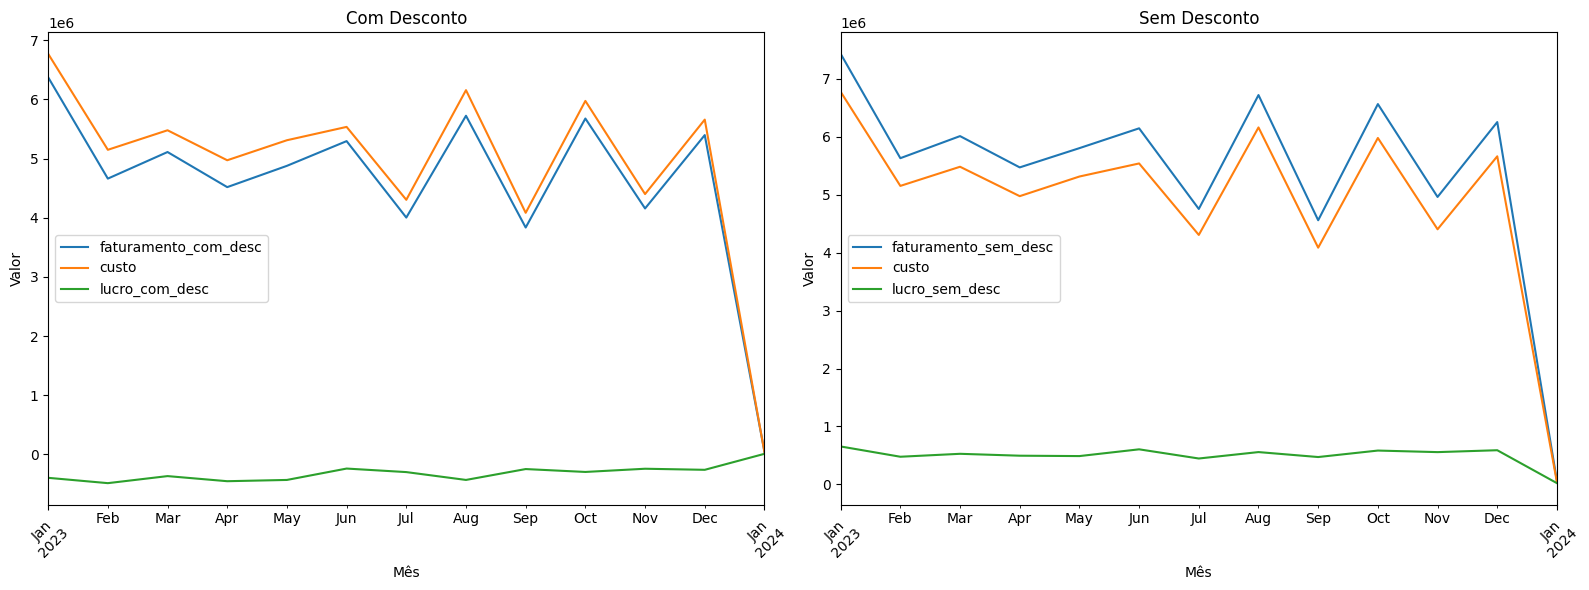

In [10]:
df["mes"] = df["Sale_Date"].dt.to_period('M')

mensal_com_desc = df.groupby("mes").agg({
    "faturamento_com_desc": "sum",
    "custo": "sum",
    "lucro_com_desc": "sum"
})

mensal_sem_desc = df.groupby("mes").agg({
    "faturamento_sem_desc": "sum",
    "custo": "sum",
    "lucro_sem_desc": "sum"
})

fig, axes = plt.subplots(1, 2, figsize = (16, 6))  # 1 linha, 2 colunas

# Com desconto
mensal_com_desc.plot(ax = axes[0])
axes[0].set_title("Com Desconto")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Valor")
axes[0].tick_params(axis="x", rotation = 45)

# Sem desconto
mensal_sem_desc.plot(ax = axes[1])
axes[1].set_title("Sem Desconto")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Valor")
axes[1].tick_params(axis = "x", rotation = 45)

plt.tight_layout()
plt.show()

<h2>Interpretação da Evolução Mensal</h2>

<p style="font-size:17px;">No cenário com desconto, observa-se que, embora o faturamento se mantenha em patamares relevantes ao longo dos meses, a redução da receita líquida pressiona o resultado operacional, fazendo com que o lucro apresente maior volatilidade e, em determinados períodos, fique mais próximo do ponto de equilíbrio ou até negativo.</p>
<p style="font-size:17px;">No cenário sem desconto, a trajetória do faturamento permanece superior, refletindo diretamente em níveis de lucro mais consistentes ao longo do tempo. Como o custo tende a acompanhar o volume de vendas, a principal diferença entre os dois cenários está no efeito dos descontos sobre a margem final.</p>
<p style="font-size:17px;">De forma geral, a análise mensal indica que a política de descontos reduz a capacidade de geração de resultado, ainda que o comportamento sazonal das vendas permaneça semelhante entre os dois cenários.</p>

---

<h2>Gráfico de Desconto vs Margem</h2>

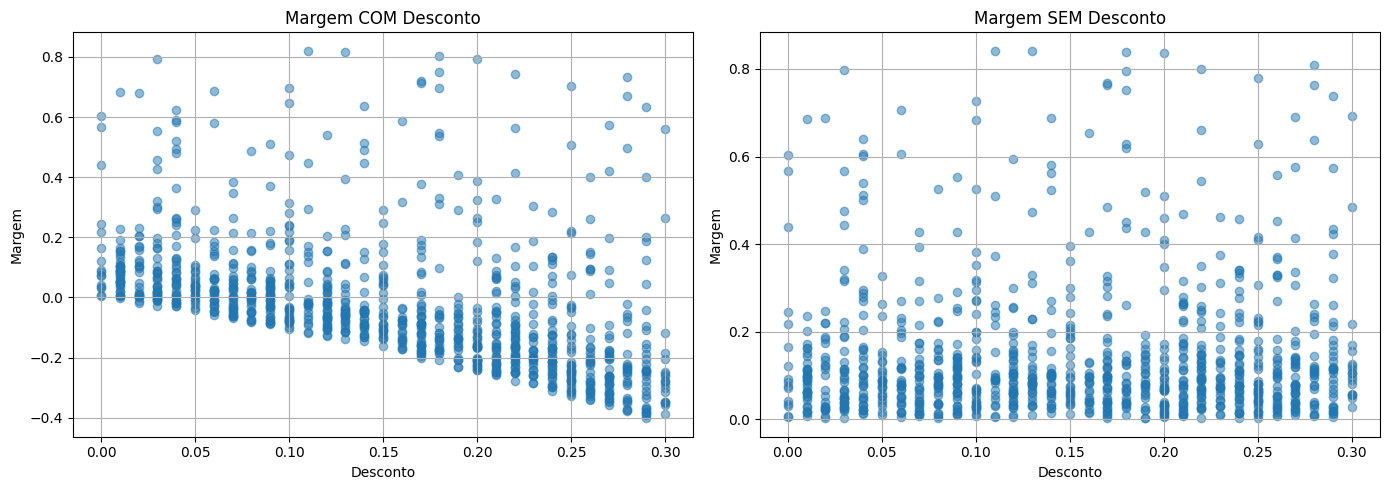

In [11]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Com desconto
axes[0].scatter(df["Discount"], df["margem_com_desc"], alpha = 0.5)
axes[0].set_title("Margem COM Desconto")
axes[0].set_xlabel("Desconto")
axes[0].set_ylabel("Margem")
axes[0].grid(True)

# Sem desconto
axes[1].scatter(df["Discount"], df["margem_sem_desc"], alpha = 0.5)
axes[1].set_title("Margem SEM Desconto")
axes[1].set_xlabel("Desconto")
axes[1].set_ylabel("Margem")
axes[1].grid(True)

plt.tight_layout()
plt.show()

<h2>Interpretação de Desconto vs Margem</h2>

<p style="font-size:17px;">O gráfico de dispersão mostra a relação entre o percentual de desconto e a margem de lucro das vendas.</p>
<p style="font-size:17px;">No cenário com desconto, observa-se uma tendência de redução da margem à medida que o desconto aumenta. Embora exista dispersão entre os pontos, a concentração de valores em faixas de margem mais baixas — inclusive negativas — indica que descontos mais elevados tendem a pressionar diretamente a rentabilidade das operações.</p>
<p style="font-size:17px;">No cenário sem desconto, a margem permanece majoritariamente positiva e mais estável, sem apresentar deterioração acentuada ao longo dos diferentes níveis de desconto. Isso ocorre porque, nesse caso, a margem é calculada com base no preço cheio, preservando maior capacidade de geração de lucro.</p>
<p style="font-size:17px;">De forma geral, o gráfico sugere que o aumento dos descontos está associado à compressão das margens, reforçando que a política comercial impacta diretamente o resultado financeiro.</p>

---

<h2>Gráfico de Análise comparativa do lucro por região e categoria</h2>

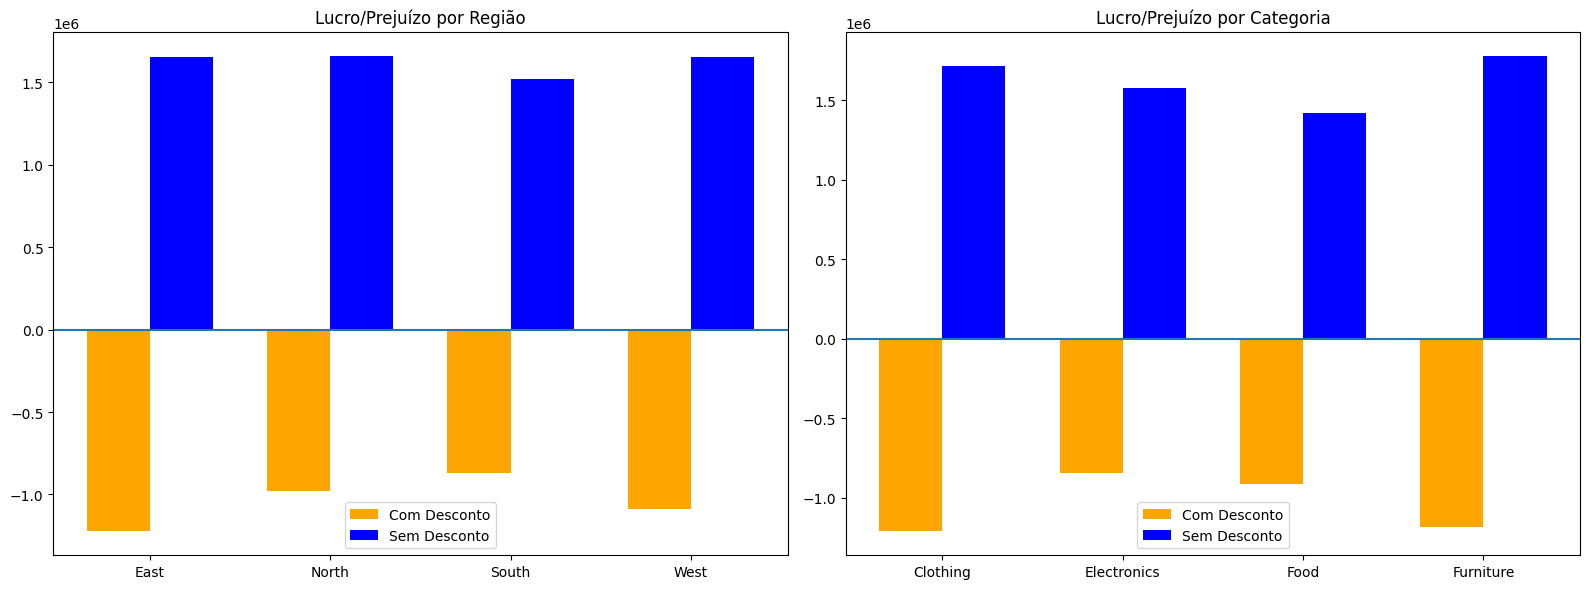

In [12]:
# Agrupamento
df_region = df.groupby("Region")[["lucro_com_desc", "lucro_sem_desc"]].sum().reset_index()
df_category = df.groupby("Product_Category")[["lucro_com_desc", "lucro_sem_desc"]].sum().reset_index()

# Configuração
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

width = 0.35

# Gráfico 1 - Região
x1 = np.arange(len(df_region))

axes[0].bar(x1 - width/2, df_region['lucro_com_desc'], width, label = 'Com Desconto', color = "orange")
axes[0].bar(x1 + width/2, df_region['lucro_sem_desc'], width, label = 'Sem Desconto', color = 'blue')

axes[0].axhline(0)
axes[0].set_title("Lucro/Prejuízo por Região")
axes[0].set_xticks(x1)
axes[0].set_xticklabels(df_region["Region"])
axes[0].legend()

# Gráfico 2 - Categoria
x2 = np.arange(len(df_category))

axes[1].bar(x2 - width/2, df_category["lucro_com_desc"], width, label="Com Desconto", color = "orange")
axes[1].bar(x2 + width/2, df_category["lucro_sem_desc"], width, label="Sem Desconto", color = "blue")

axes[1].axhline(0)
axes[1].set_title("Lucro/Prejuízo por Categoria")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(df_category["Product_Category"])
axes[1].legend()

# Ajuste
plt.tight_layout()
plt.show()

<h2>Interpretação da Análise comparativa de lucro por região e categoria</h2>

<p style="font-size:17px;">O gráfico de barras compara o desempenho do lucro com desconto e sem desconto, permitindo avaliar o impacto da política comercial em diferentes segmentos do negócio.</p>
<p style="font-size:17px;">Na análise por região, observa-se que o cenário sem desconto apresenta resultados superiores em praticamente todas as localidades, indicando que os descontos reduzem de forma consistente a rentabilidade regional. A diferença entre as barras também sugere que algumas regiões são mais sensíveis à política de descontos do que outras, apresentando maior compressão de margem.</p>
<p style="font-size:17px;">Na análise por categoria de produto, o comportamento é semelhante. Em geral, o lucro sem desconto permanece acima do lucro com desconto, evidenciando que o impacto dos descontos não ocorre de forma homogênea entre as categorias. Algumas linhas de produto conseguem preservar parte da rentabilidade, enquanto outras apresentam redução mais acentuada no resultado.</p>
<p style="font-size:17px;">De forma geral, o gráfico indica que, embora os descontos possam contribuir para a dinâmica comercial, seu efeito financeiro tende a reduzir o lucro em diferentes regiões e categorias, reforçando a importância de avaliar a concessão de descontos de forma segmentada.</p>

---

<h2>Gráfico de impacto do desconto sobre o lucro</h2>

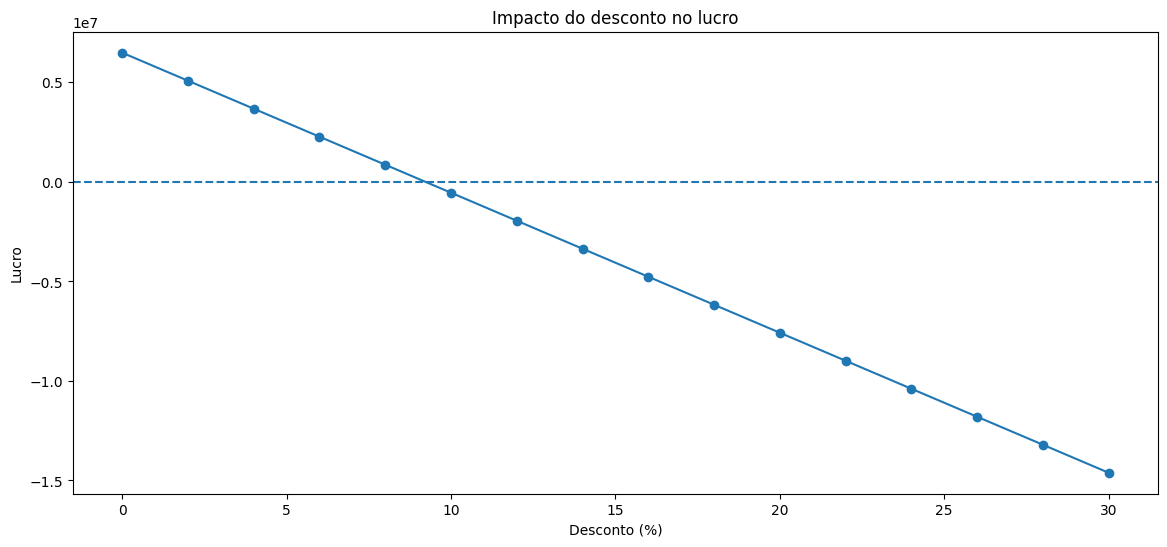

In [13]:
# cenários de desconto
cenarios = np.arange(0, 0.31, 0.02)   # de 0% até 30%

resultados = []

for desconto in cenarios:
    preco_com_desc = df['Unit_Price'] * (1 - desconto)
    faturamento = (preco_com_desc * df['Quantity_Sold']).sum()
    custo = (df['Unit_Cost'] * df['Quantity_Sold']).sum()
    lucro = faturamento - custo
    margem = lucro / faturamento if faturamento != 0 else 0

    resultados.append([desconto, faturamento, lucro, margem])

simulacao = pd.DataFrame(
    resultados,
    columns=['desconto', 'faturamento', 'lucro', 'margem']
)

plt.figure(figsize=(14,6))

plt.plot(simulacao['desconto'] * 100,
         simulacao['lucro'],
         marker='o')

plt.axhline(0, linestyle='--')

plt.title('Impacto do desconto no lucro')
plt.xlabel('Desconto (%)')
plt.ylabel('Lucro')

plt.show()

<h2>Interpretação do impacto do desconto sobre o lucro</h2>

<p style="font-size:17px;">O gráfico de simulação mostra a relação entre o percentual de desconto aplicado e o lucro total estimado da operação, assumindo que o volume vendido e a estrutura de custos permanecem constantes.</p>

<p style="font-size:17px;">Observa-se uma trajetória claramente descendente: à medida que o desconto aumenta, o lucro se reduz de forma progressiva.</p>

<p style="font-size:17px;">Esse comportamento ocorre porque a redução do preço afeta diretamente o faturamento, enquanto o custo total permanece praticamente inalterado. Como consequência, cada incremento no nível de desconto comprime a margem operacional e reduz a capacidade de geração de resultado.</p>

<p style="font-size:17px;">O ponto mais relevante do gráfico é a interseção da reta com a linha de lucro zero.</p>

<p style="font-size:17px;">Esse ponto representa o limite econômico de equilíbrio da política comercial.</p>

---

<h2>14. Comparação de Métricas com e sem Descontos</h2>

In [14]:
def lista_kpis(df):
    print("🔍 COMPARAÇÃO DE MÉTRICAS COM E SEM DESCONTOS")
    # Métricas gerais
    faturamento_total_sem_desc = df["faturamento_sem_desc"].sum()
    faturamento_total_com_desc = df["faturamento_com_desc"].sum()
    custo_total = df["custo"].sum()
    lucro_total_sem_desc = df["lucro_sem_desc"].sum()
    lucro_total_com_desc = df["lucro_com_desc"].sum()
    
    quantidade_vendida = df["Quantity_Sold"].sum()
    total_vendas = len(df)
    
    # Ticket médio com e sem descontos
    ticket_medio_sem_desc = faturamento_total_sem_desc / total_vendas
    ticket_medio_com_desc = faturamento_total_com_desc / total_vendas
    
    # Margens com e sem descontos
    margem_sem_desc = lucro_total_sem_desc / faturamento_total_sem_desc
    margem_com_desc = lucro_total_com_desc / faturamento_total_com_desc
    
    metricas_vendas = pd.DataFrame({
        'Métricas': [
            "Faturamento sem descontos", 
            "Faturamento com descontos", 
            "custo_total",
            "Lucro sem desconto", 
            "Lucro com desconto",
            "Quantidade vendida",
            "Total de vendas",
            "Ticket médio sem descontos",
            "Ticket médio com descontos",
            "Margem sem descontos",
            "Margem com descontos"
        ],
        'Valores': [
            f"$ {faturamento_total_sem_desc:,.2f}", 
            f"$ {faturamento_total_com_desc:,.2f}", 
            f"$ {custo_total:,.2f}",  
            f"$ {lucro_total_sem_desc:,.2f}",  
            f"$ {lucro_total_com_desc:,.2f}", 
            quantidade_vendida,
            total_vendas,
            f"$ {ticket_medio_sem_desc:,.2f}", 
            f"$ {ticket_medio_com_desc:,.2f}", 
            f"{round((margem_sem_desc * 100), 2)}%", 
            f"{round((margem_com_desc * 100), 2)}%" 
        ]
    })
    print(metricas_vendas)

lista_kpis(df)

🔍 COMPARAÇÃO DE MÉTRICAS COM E SEM DESCONTOS
                      Métricas          Valores
0    Faturamento sem descontos  $ 70,329,940.71
1    Faturamento com descontos  $ 59,686,173.28
2                  custo_total  $ 63,842,093.64
3           Lucro sem desconto   $ 6,487,847.07
4           Lucro com desconto  $ -4,155,920.36
5           Quantidade vendida            25355
6              Total de vendas             1000
7   Ticket médio sem descontos      $ 70,329.94
8   Ticket médio com descontos      $ 59,686.17
9         Margem sem descontos            9.22%
10        Margem com descontos           -6.96%


<h2>Interpretação das métricas consolidadas</h2>

<p style="font-size:17px;">A comparação entre os cenários com e sem desconto mostra um impacto financeiro bastante relevante da política comercial sobre o desempenho da operação.</p>

<p style="font-size:17px;">Sem descontos, o faturamento total alcançaria 70,33 milhões. Com a aplicação dos descontos observados na base, esse valor cai para 59,69 milhões, uma redução de aproximadamente 10,64 milhões, ou cerca de 15,1% da receita potencial.</p>

<p style="font-size:17px;">Embora o custo total permaneça em 63,84 milhões, a redução de receita altera completamente o resultado operacional.</p>

<p style="font-size:17px;">No cenário sem desconto, a operação geraria 6,49 milhões de lucro, com margem positiva de 9,22%. Já no cenário com desconto, o resultado se torna negativo em 4,16 milhões, levando a margem para -6,96%.</p>

---

<h2>15. Efeito progressivo dos descontos sobre o lucro</h2>

In [15]:
# descontos que você quer simular
descontos = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.15, 0.2, 0.25]

# base sem desconto
faturamento_base = (df['Unit_Price'] * df['Quantity_Sold']).sum()
custo_total = (df['Unit_Cost'] * df['Quantity_Sold']).sum()

linhas = []

for d in descontos:
    faturamento = faturamento_base * (1 - d)
    lucro = faturamento - custo_total
    margem = (lucro / faturamento) if faturamento != 0 else 0

    linhas.append({
        'Desconto': f'{d:.0%}',
        'Faturamento': faturamento,
        'Lucro': lucro,
        'Margem': margem
    })

tabela = pd.DataFrame(linhas)

# formatação opcional
tabela['Faturamento'] = tabela['Faturamento'].map(lambda x: f'{x:,.2f}')
tabela['Lucro'] = tabela['Lucro'].map(lambda x: f'{x:,.2f}')
tabela['Margem'] = tabela['Margem'].map(lambda x: f'{x:.1%}')

print(tabela)

   Desconto    Faturamento           Lucro  Margem
0        0%  70,329,940.71    6,487,847.07    9.2%
1        1%  69,626,641.30    5,784,547.66    8.3%
2        2%  68,923,341.90    5,081,248.26    7.4%
3        3%  68,220,042.49    4,377,948.85    6.4%
4        4%  67,516,743.08    3,674,649.44    5.4%
5        5%  66,813,443.67    2,971,350.03    4.4%
6        6%  66,110,144.27    2,268,050.63    3.4%
7        7%  65,406,844.86    1,564,751.22    2.4%
8        8%  64,703,545.45      861,451.81    1.3%
9        9%  64,000,246.05      158,152.41    0.2%
10      10%  63,296,946.64     -545,147.00   -0.9%
11      15%  59,780,449.60   -4,061,644.04   -6.8%
12      20%  56,263,952.57   -7,578,141.07  -13.5%
13      25%  52,747,455.53  -11,094,638.11  -21.0%


<h2>A descoberta principal — existe um ponto crítico</h2>
<p style="font-size:17px;">Foi realizada uma simulação para avaliar o efeito progressivo dos descontos sobre o lucro.</p>
<p style="font-size:17px;">O resultado mostrou um ponto de ruptura bastante claro.</p>
<h3>Faixa de equilíbrio</h3>
<p style="font-size:17px;">até aproximadamente 9% de desconto, o negócio ainda permanece próximo do equilíbrio</p>
<h3>Ponto crítico</h3>
<p style="font-size:17px;">a partir de 9%, o lucro passa a ser negativo</p>

---

<h2>16. Conclusão executiva</h2>

<p style="font-size:17px;">A análise mostra que:</p>
<h3>A operação é economicamente viável sem descontos</h3>
<p style="font-size:17px;">A estrutura de custos e preços permite geração positiva de lucro.</p>
<h3>A política atual de descontos compromete a rentabilidade</h3>
<p style="font-size:17px;">O desconto médio observado (15,24%) já se encontra acima da faixa economicamente saudável.</p>
<h3>O principal problema não é vender pouco</h3>
<p style="font-size:17px;">O principal problema é vender com margem insuficiente.</p>

---

<h2>17. Recomendações de negócio</h2>

<p style="font-size:17px;">Com base nos achados, três recomendações práticas se destacam.</p>
<h3>Revisar o teto de desconto</h3>
<p style="font-size:17px;">O desconto acima de 9% deve ser tratado como zona de atenção.</p>
<h3>Segmentar a política comercial</h3>
<p style="font-size:17px;">Descontos devem ser diferenciados por:</p>
<ul style="font-size:17px;">
    <li>região</li>
    <li>categoria</li>
    <li>perfil de cliente</li>
    <li>canal de venda</li>
</ul>
<h3>Tratar desconto como alavanca tática</h3>
<p style="font-size:17px;">Desconto deve ser ferramenta de estímulo comercial, e não prática recorrente que comprometa margem.</p>
<h3>Política sugerida</h3>
<ul style="font-size:17px;">
    <li>até 5% → desconto liberado</li>
    <li>5% a 9% → permitido com justificativa comercial</li>
    <li>acima de 9% → apenas campanhas específicas ou clientes estratégicos</li>
</ul>

---

<h2>18. Encerramento</h2>

<p style="font-size:17px;">Este estudo mostra que aumentar vendas nem sempre significa aumentar resultado.</p>
<p style="font-size:17px;">A empresa continua vendendo.</p>
<p style="font-size:17px;">Mas, ao conceder descontos em níveis excessivos, parte relevante dessas vendas deixa de gerar valor econômico.</p>
<h3>O verdadeiro desafio não é vender mais. É vender preservando rentabilidade.</h3>

---

<h2>19. Sobre o autor</h2>

* Autor: Carlos da Costa
* Recife, PE - Brasil<br>
* Telefone: +55 81 99712 9140<br>
* Telegram: @jcarlossc<br>
* Blogger linguagem R: [https://informaticus77-r.blogspot.com/](https://informaticus77-r.blogspot.com/)<br>
* Blogger linguagem Python: [https://informaticus77-python.blogspot.com/](https://informaticus77-python.blogspot.com/)<br>
* Email: jcarlossc1977@gmail.com<br>
* LinkedIn: https://www.linkedin.com/in/carlos-da-costa-669252149/<br>
* GitHub: https://github.com/jcarlossc<br>
* Kaggle: https://www.kaggle.com/jcarlossc/  
* Twitter/X: https://x.com/jcarlossc1977

---